# AI药物设计 - 第5课：神经网络基础

## 学习目标
1. 理解神经网络如何拟合非线性数据
2. 掌握神经网络训练的4个步骤
3. 使用PyTorch简化神经网络实现

## 1. 导入必要的库

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子
np.random.seed(42)
torch.manual_seed(42)

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

## 2. 数据准备与可视化

我们使用一个药物剂量-效应数据集，这是一个**非线性关系**（S型曲线），线性模型无法很好拟合。

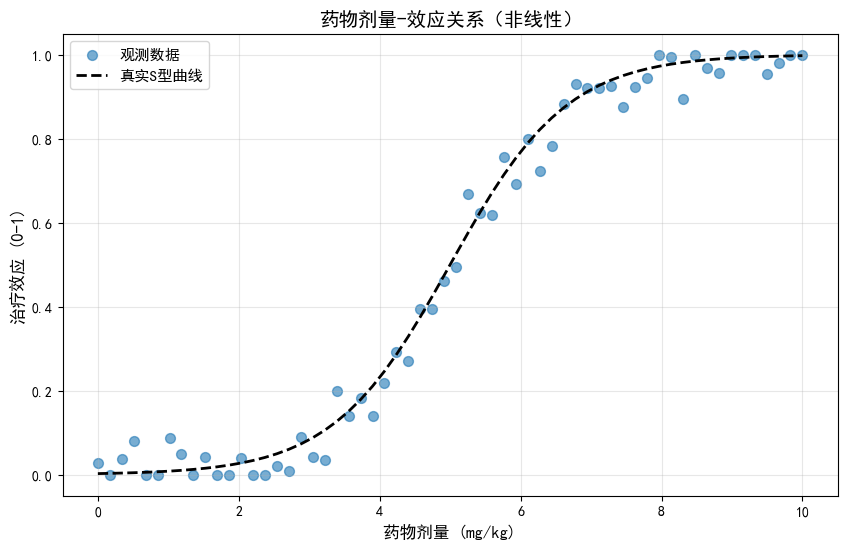

数据集大小: 60 个样本
输入范围: [0.00, 1.00]
输出范围: [0.00, 1.00]


In [2]:
# 生成药物剂量-效应数据（非线性）
np.random.seed(42)
doses = np.linspace(0, 10, 60).reshape(-1, 1)

# 真实的S型剂量-效应曲线
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

true_effect = sigmoid(1.2 * (doses - 5))
noise = np.random.normal(0, 0.05, size=true_effect.shape)
observed_effect = np.clip(true_effect + noise, 0, 1)

# 特征归一化到[0,1]
X = doses / 10
y = observed_effect.flatten()

# 可视化数据
plt.figure(figsize=(10, 6))
plt.scatter(doses, y, alpha=0.6, s=50, label='观测数据')
plt.plot(doses, true_effect, 'k--', linewidth=2, label='真实S型曲线')
plt.xlabel('药物剂量 (mg/kg)', fontsize=12)
plt.ylabel('治疗效应 (0-1)', fontsize=12)
plt.title('药物剂量-效应关系（非线性）', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print(f"数据集大小: {len(X)} 个样本")
print(f"输入范围: [{X.min():.2f}, {X.max():.2f}]")
print(f"输出范围: [{y.min():.2f}, {y.max():.2f}]")

## 3. 手写神经网络实现

### 网络结构
```
输入层(1个特征) → 隐藏层(8个神经元, ReLU) → 输出层(1个神经元, Sigmoid)
```

### 训练的4个步骤（和线性回归完全一样！）
1. **前向传播**：计算预测值
2. **计算损失**：MSE损失
3. **反向传播**：计算梯度
4. **更新参数**：梯度下降

In [3]:
# 激活函数定义
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid_fn(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid_fn(z)
    return s * (1 - s)

In [4]:
# 步骤1: 前向传播
def forward_pass(X, W1, b1, W2, b2):
    """两层神经网络前向传播"""
    # 第一层: 输入 → 隐藏层
    Z1 = X @ W1.T + b1      # 线性变换
    A1 = relu(Z1)            # ReLU激活
    
    # 第二层: 隐藏层 → 输出
    Z2 = A1 @ W2.T + b2     # 线性变换
    A2 = sigmoid_fn(Z2)      # Sigmoid激活
    
    # 保存中间结果供反向传播使用
    cache = {'X': X, 'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache

In [5]:
# 步骤3: 反向传播（计算梯度）
def backward_pass(cache, y_true, W2):
    """计算所有参数的梯度"""
    n = len(y_true)
    X = cache['X']
    A1 = cache['A1']
    A2 = cache['A2']
    Z1 = cache['Z1']
    Z2 = cache['Z2']
    
    # 输出层梯度
    dZ2 = A2 - y_true.reshape(-1, 1)        # 损失对Z2的梯度
    dW2 = (1/n) * dZ2.T @ A1                 # 损失对W2的梯度
    db2 = (1/n) * np.sum(dZ2, axis=0)        # 损失对b2的梯度
    
    # 隐藏层梯度（链式法则）
    dA1 = dZ2 @ W2                           # 损失对A1的梯度
    dZ1 = dA1 * relu_derivative(Z1)          # 损失对Z1的梯度
    dW1 = (1/n) * dZ1.T @ X                  # 损失对W1的梯度
    db1 = (1/n) * np.sum(dZ1, axis=0)        # 损失对b1的梯度
    
    return dW1, db1, dW2, db2

In [6]:
# 初始化神经网络参数
np.random.seed(0)
hidden_size = 8

# 随机初始化权重和偏置
W1 = np.random.randn(hidden_size, 1) * 0.3   # (8, 1)
b1 = np.zeros(hidden_size)                    # (8,)
W2 = np.random.randn(1, hidden_size) * 0.3   # (1, 8)
b2 = np.zeros(1)                              # (1,)

# 训练超参数
learning_rate = 0.1
epochs = 2000
losses = []

print("=== 开始训练神经网络 ===")
print(f"网络结构: 1 → 8 → 1")
print(f"学习率: {learning_rate}")
print(f"训练轮数: {epochs}\n")

for epoch in range(epochs):
    # 步骤1: 前向传播
    y_pred, cache = forward_pass(X, W1, b1, W2, b2)
    
    # 步骤2: 计算损失
    loss = np.mean((y_pred.flatten() - y) ** 2)  # MSE
    losses.append(loss)
    
    # 步骤3: 反向传播（计算梯度）
    dW1, db1, dW2, db2 = backward_pass(cache, y, W2)
    
    # 步骤4: 更新参数（梯度下降）
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1:4d} | Loss: {loss:.6f}")

print("\n训练完成！")

=== 开始训练神经网络 ===
网络结构: 1 → 8 → 1
学习率: 0.1
训练轮数: 2000

Epoch  500 | Loss: 0.005124
Epoch 1000 | Loss: 0.001893
Epoch 1500 | Loss: 0.001627
Epoch 2000 | Loss: 0.001585

训练完成！


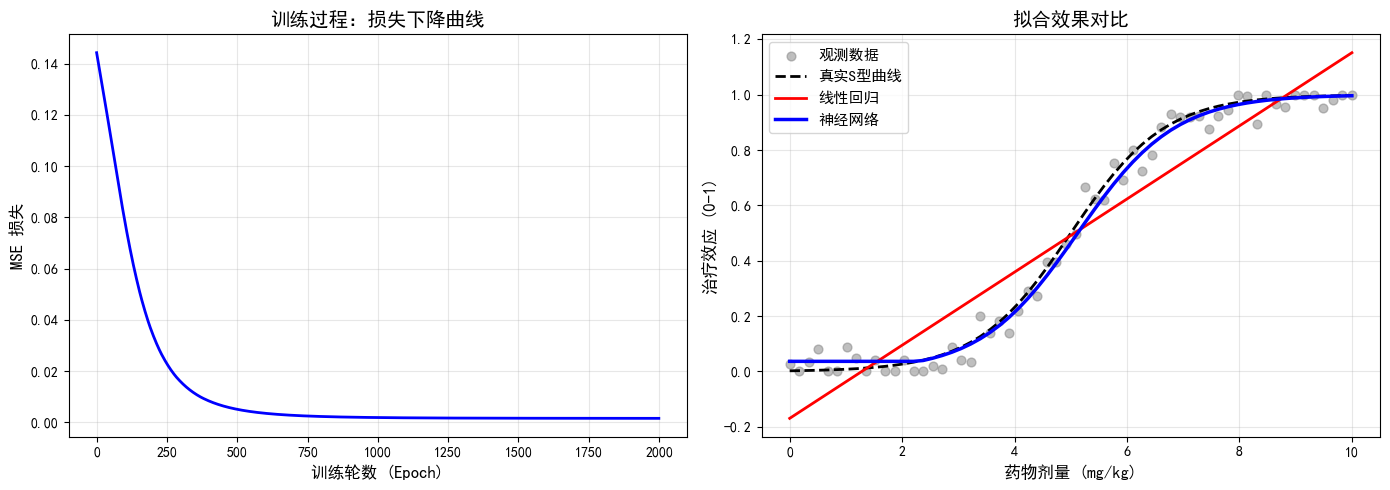


模型性能对比：
线性回归 MSE: 0.012132
神经网络 MSE: 0.000466
性能提升: 96.2%


In [7]:
# 可视化训练结果
y_pred_manual, _ = forward_pass(X, W1, b1, W2, b2)

# 对比线性回归
linear_coef = np.polyfit(doses.flatten(), y, 1)
linear_pred = np.polyval(linear_coef, doses.flatten())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：损失曲线
axes[0].plot(losses, 'b-', linewidth=2)
axes[0].set_xlabel('训练轮数 (Epoch)', fontsize=12)
axes[0].set_ylabel('MSE 损失', fontsize=12)
axes[0].set_title('训练过程：损失下降曲线', fontsize=14)
axes[0].grid(True, alpha=0.3)

# 右图：拟合效果对比
axes[1].scatter(doses, y, alpha=0.5, s=40, label='观测数据', color='gray')
axes[1].plot(doses, true_effect, 'k--', linewidth=2, label='真实S型曲线')
axes[1].plot(doses, linear_pred, 'r-', linewidth=2, label='线性回归')
axes[1].plot(doses, y_pred_manual, 'b-', linewidth=2.5, label='神经网络')
axes[1].set_xlabel('药物剂量 (mg/kg)', fontsize=12)
axes[1].set_ylabel('治疗效应 (0-1)', fontsize=12)
axes[1].set_title('拟合效果对比', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 计算最终误差
linear_mse = np.mean((linear_pred - true_effect.flatten())**2)
nn_mse = np.mean((y_pred_manual.flatten() - true_effect.flatten())**2)

print(f"\n模型性能对比：")
print(f"线性回归 MSE: {linear_mse:.6f}")
print(f"神经网络 MSE: {nn_mse:.6f}")
print(f"性能提升: {(1 - nn_mse/linear_mse)*100:.1f}%")

## 4. PyTorch实现

手写神经网络帮助我们理解原理，但实际应用中我们使用**PyTorch**：
- ✅ **自动求导**：不需要手动推导梯度公式
- ✅ **GPU加速**：支持大规模数据训练
- ✅ **代码简洁**：几行代码完成复杂网络

In [8]:
# 定义神经网络（PyTorch风格）
class DrugNet(nn.Module):
    def __init__(self, input_size=1, hidden_size=8, output_size=1):
        super(DrugNet, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)   # 输入层→隐藏层
        self.layer2 = nn.Linear(hidden_size, output_size)  # 隐藏层→输出层
    
    def forward(self, x):
        h = torch.relu(self.layer1(x))       # 隐藏层 + ReLU激活
        y = torch.sigmoid(self.layer2(h))    # 输出层 + Sigmoid激活
        return y

# 创建模型
model = DrugNet(input_size=1, hidden_size=8)

print("神经网络结构:")
print(model)
print(f"\n总参数数量: {sum(p.numel() for p in model.parameters())}")
print(f"- Layer1 (W1+b1): {1*8 + 8} = 16 个参数")
print(f"- Layer2 (W2+b2): {8*1 + 1} = 9 个参数")

神经网络结构:
DrugNet(
  (layer1): Linear(in_features=1, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=1, bias=True)
)

总参数数量: 25
- Layer1 (W1+b1): 16 = 16 个参数
- Layer2 (W2+b2): 9 = 9 个参数


In [9]:
# 准备PyTorch张量
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# 定义损失函数和优化器
criterion = nn.MSELoss()                                    # 均方误差损失
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Adam优化器

# 训练循环（同样的4个步骤！）
print("=== PyTorch训练 ===\n")
model.train()
torch_losses = []

for epoch in range(2000):
    # 步骤1: 前向传播（PyTorch自动完成）
    y_pred = model(X_tensor)
    
    # 步骤2: 计算损失
    loss = criterion(y_pred, y_tensor)
    torch_losses.append(loss.item())
    
    # 步骤3+4: 反向传播 + 参数更新（PyTorch自动完成！）
    optimizer.zero_grad()   # 清空上一轮的梯度
    loss.backward()         # 自动计算梯度（反向传播）
    optimizer.step()        # 自动更新参数（梯度下降）
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1:4d} | Loss: {loss.item():.6f}")

print("\n训练完成！")

=== PyTorch训练 ===

Epoch  500 | Loss: 0.001506
Epoch 1000 | Loss: 0.001499
Epoch 1500 | Loss: 0.001497
Epoch 2000 | Loss: 0.001495

训练完成！


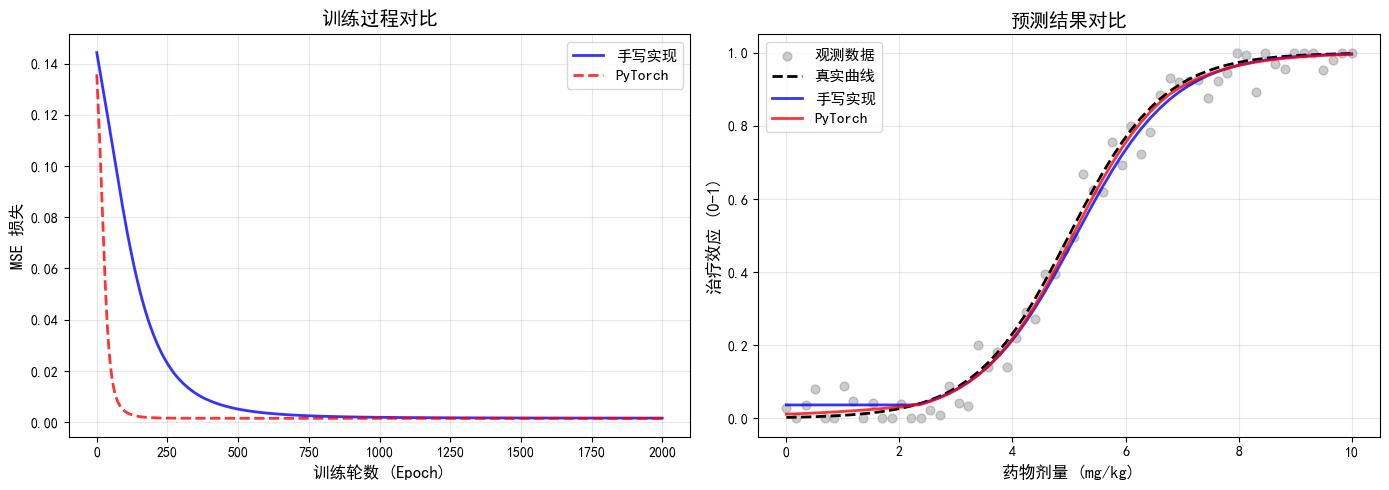


最终性能对比：
手写实现 MSE: 0.000466
PyTorch  MSE: 0.000118


In [10]:
# 评估PyTorch模型
model.eval()
with torch.no_grad():
    y_pred_torch = model(X_tensor).numpy()

# 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：训练损失对比
axes[0].plot(losses, 'b-', linewidth=2, label='手写实现', alpha=0.8)
axes[0].plot(torch_losses, 'r--', linewidth=2, label='PyTorch', alpha=0.8)
axes[0].set_xlabel('训练轮数 (Epoch)', fontsize=12)
axes[0].set_ylabel('MSE 损失', fontsize=12)
axes[0].set_title('训练过程对比', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 右图：预测结果对比
axes[1].scatter(doses, y, alpha=0.4, s=40, label='观测数据', color='gray')
axes[1].plot(doses, true_effect, 'k--', linewidth=2, label='真实曲线')
axes[1].plot(doses, y_pred_manual, 'b-', linewidth=2, label='手写实现', alpha=0.8)
axes[1].plot(doses, y_pred_torch, 'r-', linewidth=2, label='PyTorch', alpha=0.8)
axes[1].set_xlabel('药物剂量 (mg/kg)', fontsize=12)
axes[1].set_ylabel('治疗效应 (0-1)', fontsize=12)
axes[1].set_title('预测结果对比', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 性能对比
manual_mse = np.mean((y_pred_manual.flatten() - true_effect.flatten())**2)
pytorch_mse = np.mean((y_pred_torch.flatten() - true_effect.flatten())**2)

print(f"\n最终性能对比：")
print(f"手写实现 MSE: {manual_mse:.6f}")
print(f"PyTorch  MSE: {pytorch_mse:.6f}")

In [11]:
# 使用训练好的模型进行预测
model.eval()
with torch.no_grad():
    # 预测新的剂量
    new_doses = torch.tensor([[0.3], [0.5], [0.7]], dtype=torch.float32)  # 3, 5, 7 mg/kg
    predictions = model(new_doses)

print("=== 新剂量预测 ===")
for dose, pred in zip([3, 5, 7], predictions.numpy().flatten()):
    print(f"剂量 {dose} mg/kg → 预测效应: {pred:.3f} (约{pred*100:.0f}%)")

=== 新剂量预测 ===
剂量 3 mg/kg → 预测效应: 0.077 (约8%)
剂量 5 mg/kg → 预测效应: 0.480 (约48%)
剂量 7 mg/kg → 预测效应: 0.907 (约91%)


## 5. 总结

### 核心要点

**1. 神经网络 = 非线性拟合工具**
- 线性回归：只能拟合直线
- 神经网络：通过激活函数引入非线性，能拟合复杂曲线（S型、波浪型等）

**2. 训练步骤（和线性回归完全一样！）**
```
1. 前向传播  →  计算预测值
2. 计算损失  →  MSE = mean((y_pred - y_true)²)
3. 反向传播  →  计算梯度（链式法则）
4. 更新参数  →  W -= lr * dW
```

**3. 手写 vs PyTorch**

| 方面 | 手写实现 | PyTorch |
|------|---------|---------|  
| **梯度计算** | 手动推导公式 | `loss.backward()` 自动完成 |
| **参数更新** | 手动编写 `W -= lr*dW` | `optimizer.step()` 自动完成 |
| **优点** | 深入理解原理 | 代码简洁、支持GPU |
| **适用场景** | 学习研究 | 实际应用 |

**4. 关键代码对比**

手写实现（需要手动计算梯度）：
```python
y_pred, cache = forward_pass(X, W1, b1, W2, b2)
loss = mse_loss(y_pred, y)
dW1, db1, dW2, db2 = backward_pass(cache, y, W2)  # 手动反向传播
W1 -= lr * dW1  # 手动更新
```

PyTorch实现（自动求导）：
```python
y_pred = model(X)
loss = criterion(y_pred, y)
optimizer.zero_grad()
loss.backward()      # 自动计算梯度
optimizer.step()     # 自动更新参数
```

## 6. 课后练习

1. **调整网络结构**：将隐藏层大小改为 4 或 16，观察训练效果变化
2. **调整学习率**：尝试 `lr=0.01` 和 `lr=0.5`，看看训练速度和稳定性
3. **多层网络**：在PyTorch模型中添加第二个隐藏层，构建3层网络
4. **不同数据**：生成一个波浪型数据 `y = sin(2πx)`，用神经网络拟合